# Task 1 — Exploratory Data Analysis
## Heart Disease UCI Dataset (Cleveland)

**Objective**: Understand the dataset before modelling — distributions, missing values, class balance, and feature–target relationships.

**Dataset**: 303 patients, 13 clinical features, binary target (0 = no disease, 1 = disease).

**Column reference**
| Feature | Description |
|---------|-------------|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl |
| restecg | Resting ECG (0–2) |
| thalach | Max heart rate achieved |
| exang | Exercise-induced angina (1 = yes) |
| oldpeak | ST depression from exercise |
| slope | Slope of peak exercise ST segment |
| ca | Major vessels coloured (0–3), **has missing** |
| thal | Thalassemia type, **has missing** |
| target | 0 = no disease, 1 = disease (binarised from raw `num`) |

In [1]:
import sys
sys.path.insert(0, '..')   # so 'from src.xxx import ...' works when run from notebooks/

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_preparation import load_from_ucimlrepo, binarize_target, basic_cleaning
# from src.data_preparation import load_raw_data, binarize_target, basic_cleaning  # local CSV fallback
from src.config import NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET_COL
# from src.config import DATA_DIR   # only needed for local CSV fallback

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

## 1. Load Data

In [2]:
try:
    import truststore
    truststore.inject_into_ssl()
except Exception:
    pass

raw = load_from_ucimlrepo()
# raw = load_raw_data(DATA_DIR / 'heart_disease.csv')   # local CSV fallback

df  = basic_cleaning(binarize_target(raw))

print(f'Shape: {df.shape}   ({df.shape[0]} rows × {df.shape[1]} columns)')
df.head()

Shape: (303, 14)   (303 rows × 14 columns)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 2. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [4]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


## 3. Missing Value Analysis

In [5]:
missing = df.isnull().sum().rename('missing_count')
missing_pct = (df.isnull().mean() * 100).rename('missing_%').round(2)
missing_df = pd.concat([missing, missing_pct], axis=1)
missing_df = missing_df[missing_df['missing_count'] > 0]

print('Columns with missing values:')
print(missing_df if not missing_df.empty else '  None — all clean after binarisation')

Columns with missing values:
      missing_count  missing_%
ca                4       1.32
thal              2       0.66


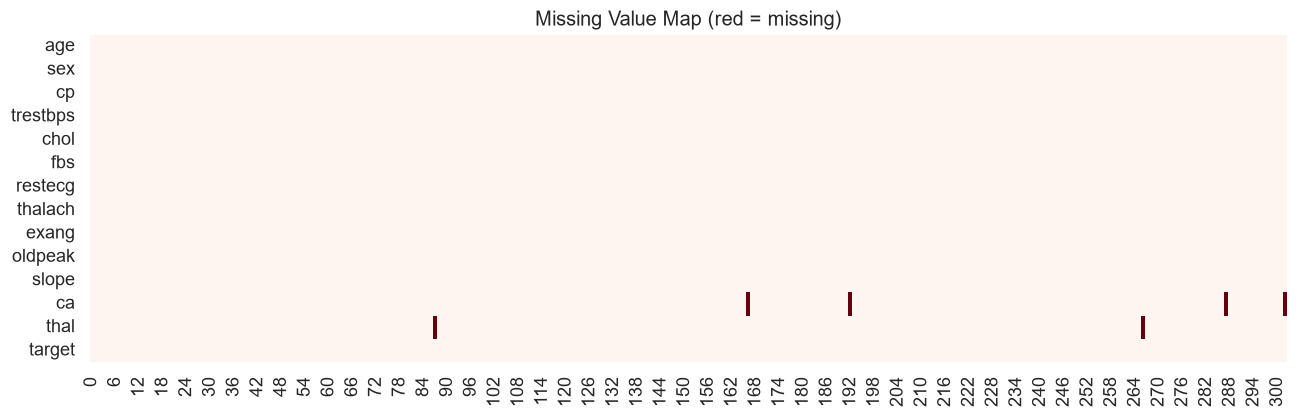

In [6]:
# Visualise missing value heatmap
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, ax=ax, cmap='Reds')
ax.set_title('Missing Value Map (red = missing)')
plt.tight_layout()
plt.show()

## 4. Class Distribution

Class counts:
        count     %
target             
0         164  54.1
1         139  45.9


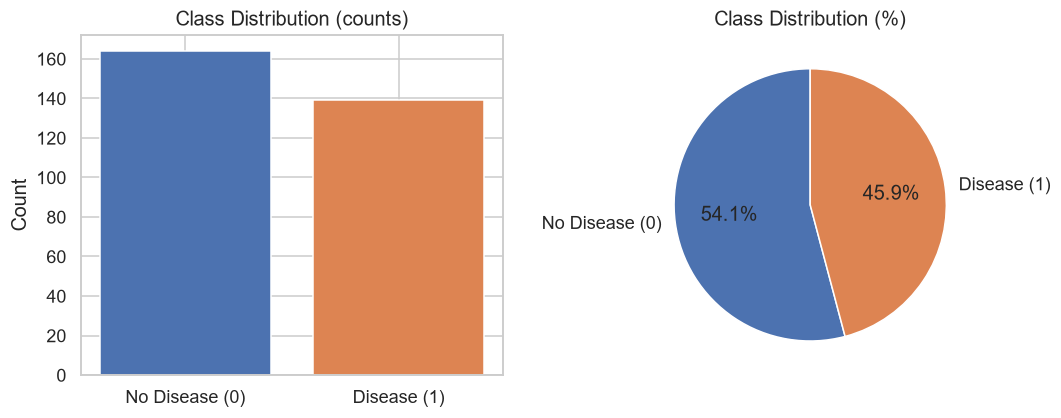

In [7]:
counts = df[TARGET_COL].value_counts()
pcts   = df[TARGET_COL].value_counts(normalize=True) * 100

print('Class counts:')
print(pd.concat([counts.rename('count'), pcts.rename('%').round(1)], axis=1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Class Distribution (counts)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Disease (0)', 'Disease (1)'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

## 5. Numeric Feature Distributions (Histograms)

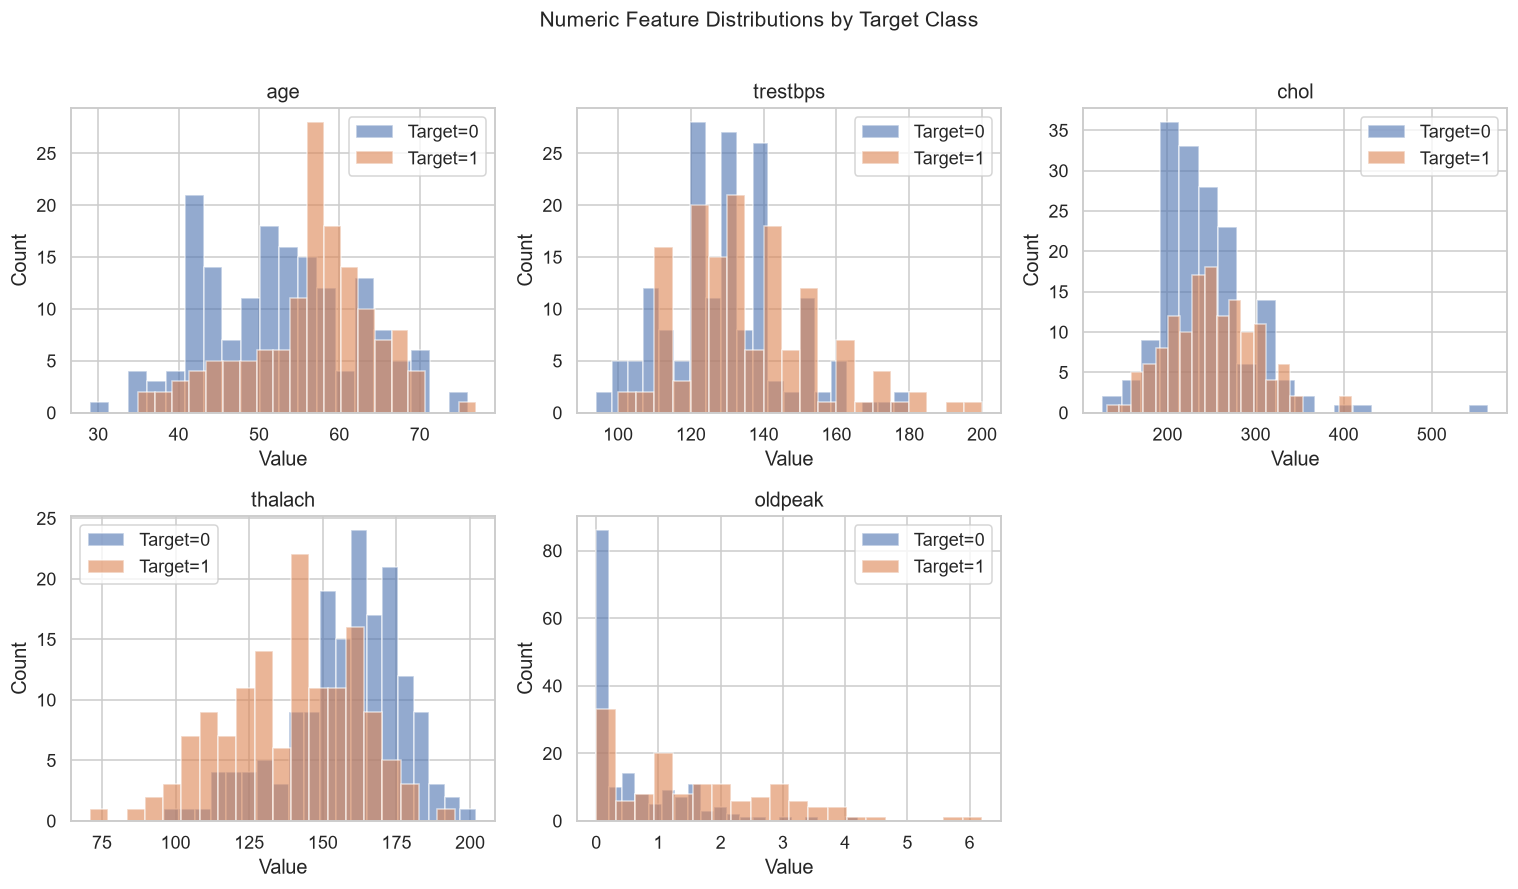

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_FEATURES):
    for label, colour in zip([0, 1], ['#4C72B0', '#DD8452']):
        axes[i].hist(df[df[TARGET_COL] == label][col].dropna(),
                     bins=20, alpha=0.6, color=colour,
                     label=f'Target={label}')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle('Numeric Feature Distributions by Target Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Categorical Feature Distributions

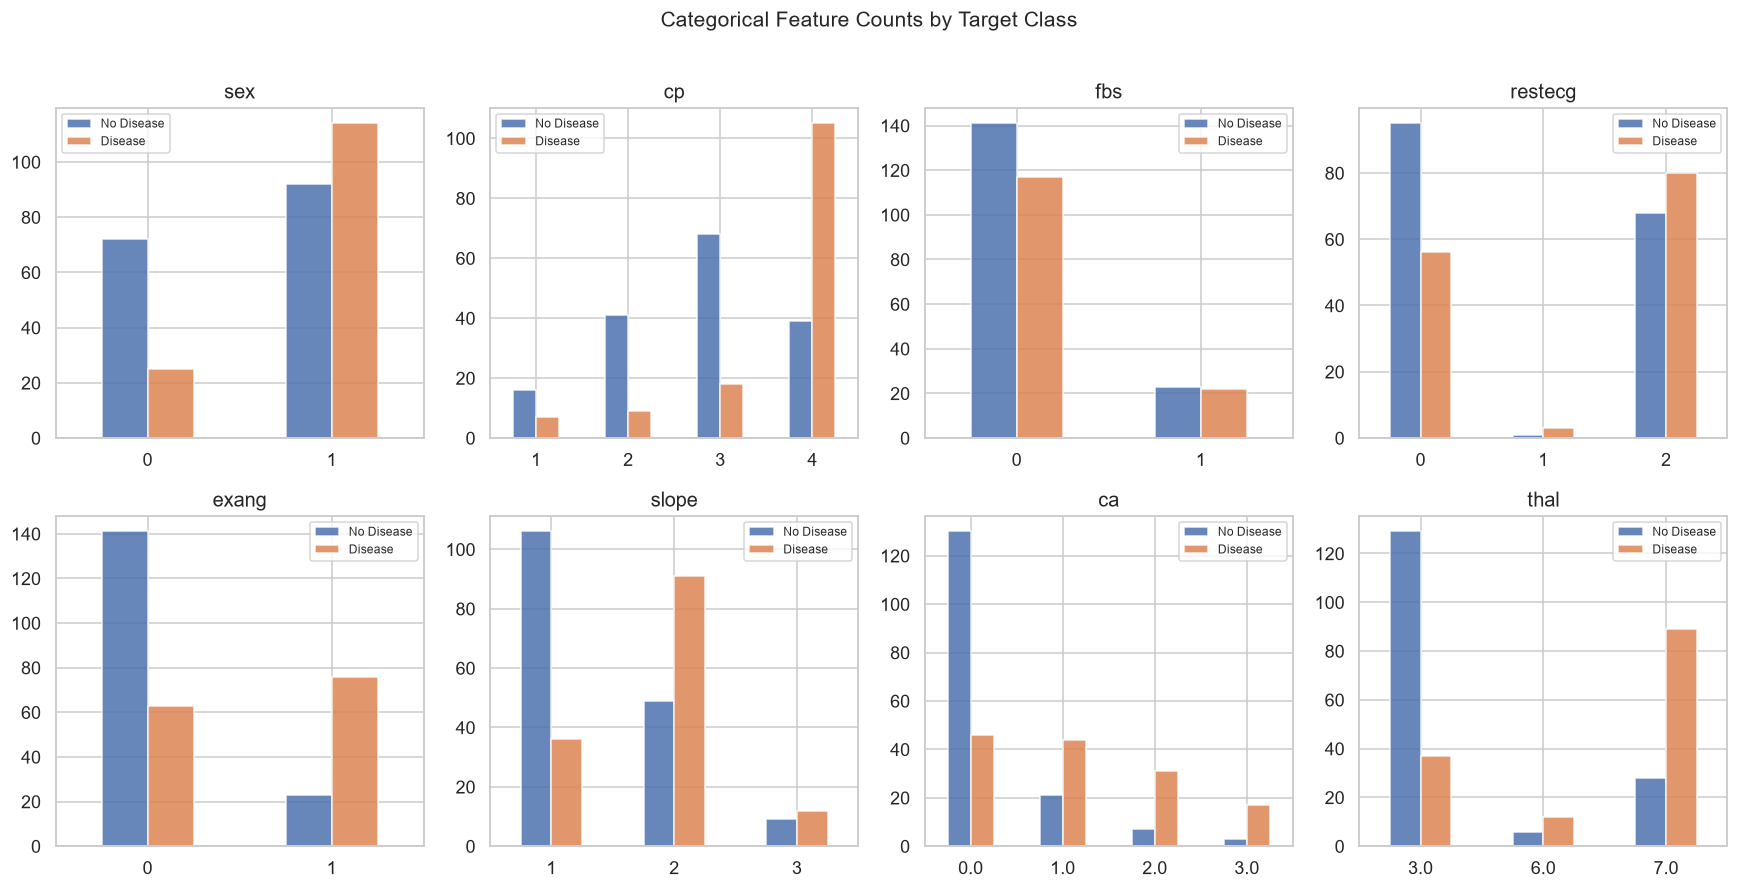

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_FEATURES):
    counts_by_class = df.groupby([col, TARGET_COL]).size().unstack(fill_value=0)
    counts_by_class.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'],
                         alpha=0.85, rot=0)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)

fig.suptitle('Categorical Feature Counts by Target Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

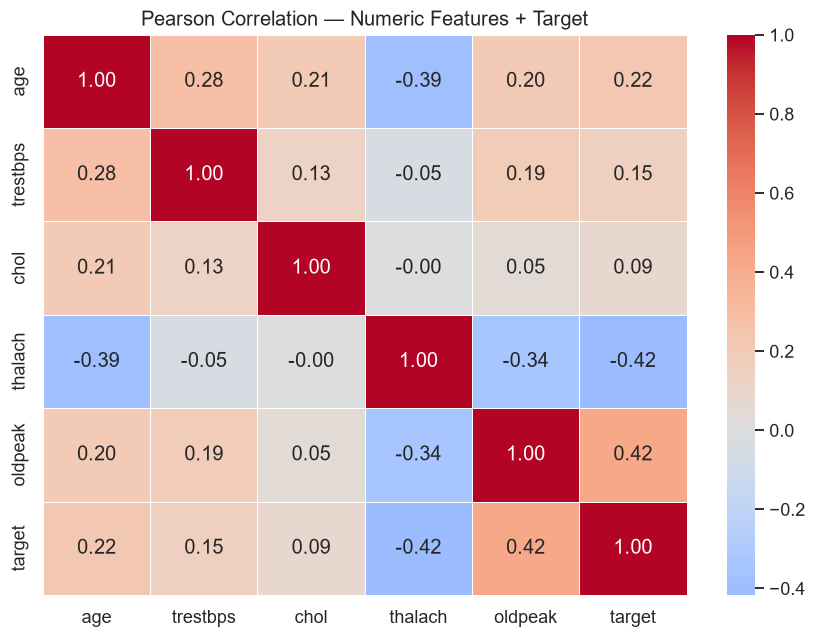

In [10]:
# Fill NaN with median for correlation calculation only
df_filled = df.fillna(df.median(numeric_only=True))

corr = df_filled[NUMERIC_FEATURES + [TARGET_COL]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Pearson Correlation — Numeric Features + Target')
plt.tight_layout()
plt.show()

## 8. Feature–Target Relationships (Box Plots)

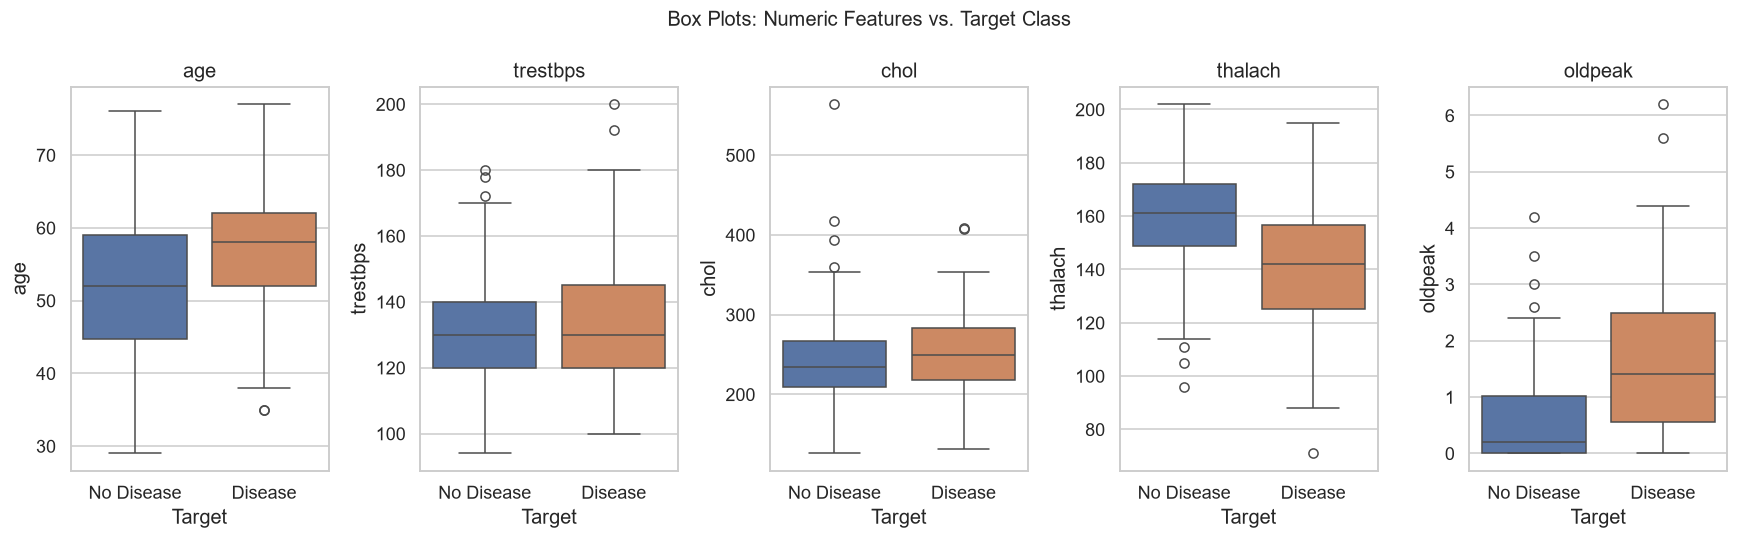

In [11]:
fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(16, 5))

for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.boxplot(
        data=df, x=TARGET_COL, y=col, ax=ax,
        palette={'0': '#4C72B0', '1': '#DD8452'}
    )
    ax.set_title(col)
    ax.set_xlabel('Target')
    ax.set_xticklabels(['No Disease', 'Disease'])

fig.suptitle('Box Plots: Numeric Features vs. Target Class', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Key Observations

| Feature | Observation |
|---------|-------------|
| **Class balance** | Dataset is roughly balanced (~54% disease, ~46% no disease) — minimal skew. |
| **thalach** | Max heart rate is *lower* in patients with disease — strong negative correlation with target. |
| **oldpeak** | ST depression is *higher* in disease patients — one of the most discriminative features. |
| **cp (chest pain type)** | Asymptomatic pain (type 0) is the most common type among disease patients. |
| **ca, thal** | Both have a small number of missing values (`?` in raw file); handled via median/mode imputation inside the sklearn Pipeline. |
| **age, trestbps, chol** | Weaker direct correlation; useful in combination with other features. |

> **Next step** → Task 2: Model development using these insights to select and tune classifiers.